<a href="https://colab.research.google.com/github/IT24100378/ToxicCommentNLPfinal/blob/Stemming-and-Lemmetising/Stemming_Lemmatization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================
# 1. Import Libraries
# ============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import re

# Download necessary resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Load SpaCy model for lemmatization
nlp = spacy.load("en_core_web_sm")

# ============================
# 2. Load Dataset
# ============================
import csv
df = pd.read_csv("preprocessed_stopwords_removed.csv", on_bad_lines='skip', engine='python')

# Rename 'tokens' → 'comment'
df.rename(columns={"tokens": "comment"}, inplace=True)

print("Dataset Shape:", df.shape)
print(df.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rznah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rznah\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\rznah\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Dataset Shape: (16000, 2)
                                             comment  toxic
0  ['lighten', 'up', 'francis', 'on', 'same', 'te...      0
1  ['lisa', 'williams', 'is', 'a', 'total', 'frau...      1
2  ['i', 'am', 'david', 'in', 'dc', 'not', 'david...      1
3  ['fuck', 'you', 'fuck', 'you', 'keep', 'blocki...      1
4  ['both', 'entries', 'are', 'on', 'the', 'same'...      0



Missing values:
 comment    0
toxic      0
dtype: int64

Class distribution:
 toxic
0    8000
1    8000
Name: count, dtype: int64


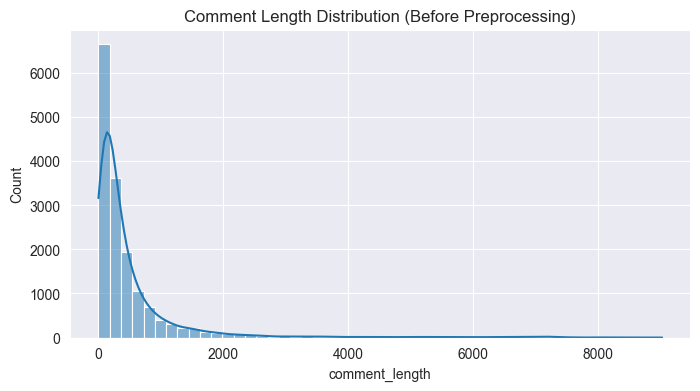

In [4]:
# ============================
# 3. EDA Before Preprocessing
# ============================
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['toxic'].value_counts())

# Comment length distribution
df['comment_length'] = df['comment'].astype(str).apply(len)

plt.figure(figsize=(8,4))
sns.histplot(df['comment_length'], bins=50, kde=True)
plt.title("Comment Length Distribution (Before Preprocessing)")
plt.show()

In [5]:
# ============================
# 4. Fast Stemming + Lemmatization
# ============================
def stem_and_lemmatize_fast(text):
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens]       # Stemming
    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatization
    return " ".join(tokens)

# Apply preprocessing
df['comment'] = df['comment'].astype(str).apply(stem_and_lemmatize_fast)

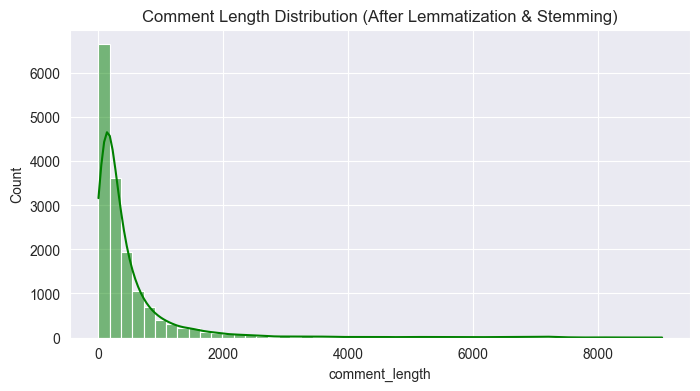


Sample preprocessed comments:
                                              comment
0  ['lighten', 'up', 'francis', 'on', 'same', 'te...
1  ['lisa', 'williams', 'is', 'a', 'total', 'frau...
2  ['i', 'am', 'david', 'in', 'dc', 'not', 'david...
3  ['fuck', 'you', 'fuck', 'you', 'keep', 'blocki...
4  ['both', 'entries', 'are', 'on', 'the', 'same'...


In [7]:
# ============================
# 5. EDA After Preprocessing
# ============================
df['comment_length'] = df['comment'].apply(len)

plt.figure(figsize=(8,4))
sns.histplot(df['comment_length'], bins=50, kde=True, color="green")
plt.title("Comment Length Distribution (After Lemmatization & Stemming)")
plt.show()

print("\nSample preprocessed comments:\n", df[['comment']].head())

In [8]:
# ============================
# 6. Save Final File
# ============================
final_df = df[['comment', 'toxic']]
final_df.to_csv("preprocessed_dataset.csv", index=False)

print("\n Preprocessed dataset saved as 'preprocessed_dataset.csv'")


 Preprocessed dataset saved as 'preprocessed_dataset.csv'
